In [1]:
import os
from pathlib import Path
import pandas as pd

if Path.cwd().name == "notebooks":
    os.chdir("..")

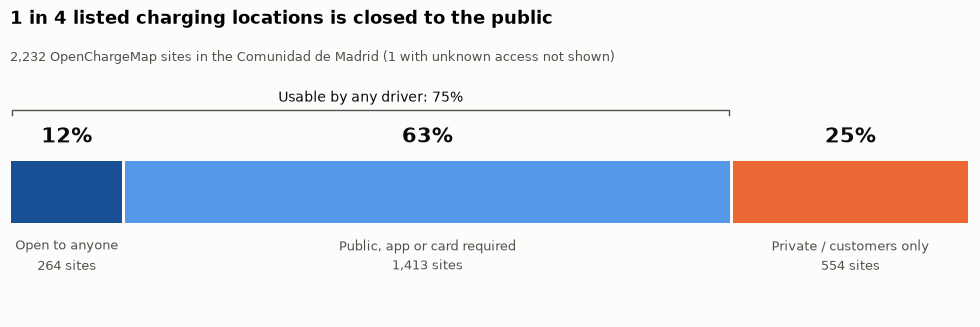

In [2]:
# Share of listed charging locations that a driver can actually use
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

ocm = pd.read_csv("data/raw/ocm/ocm_chargers.csv")
munis_ = gpd.read_file("data/raw/boundaries/municipios.gpkg")
sites = gpd.GeoDataFrame(ocm, geometry=gpd.points_from_xy(ocm["lon"], ocm["lat"]), crs=4326).to_crs(munis_.crs)
sites = gpd.sjoin(sites, munis_[["geometry"]], how="inner", predicate="within")     # inside the Comunidad only

CATS = [  # (access_class, label, colour)
    ("public",            "Open to anyone",                "#184f95"),
    ("public_membership", "Public, app or card required",  "#5598e7"),
    ("restricted",        "Private / customers only",      "#eb6834"),
]
counts = sites["access_class"].value_counts()
n_total = int(counts.sum())
n_other = n_total - int(sum(counts.get(c, 0) for c, _, _ in CATS))
share = {c: counts.get(c, 0) / n_total for c, _, _ in CATS}
usable = share["public"] + share["public_membership"]

SURFACE, INK, INK_2 = "#fcfcfb", "#0b0b0b", "#52514e"
fig, ax = plt.subplots(figsize=(10, 3.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
left = 0.0
for c, label, colour in CATS:
    w = share[c]
    ax.barh(0, w - 0.003, left=left + 0.0015, height=0.5, color=colour)         # thin gap between segments
    ax.text(left + w / 2, 0.36, f"{w:.0%}", ha="center", va="bottom", fontsize=15, fontweight="bold", color=INK)
    ax.text(left + w / 2, -0.36, f"{label}\n{counts.get(c, 0):,} sites", ha="center", va="top",
            fontsize=9.5, color=INK_2, linespacing=1.4)
    left += w

# Bracket over the usable part
y = 0.66
ax.plot([0.002, 0.002, usable - 0.002, usable - 0.002], [y - 0.04, y, y, y - 0.04], color=INK_2, lw=1)
ax.text(usable / 2, y + 0.04, f"Usable by any driver: {usable:.0%}", ha="center", va="bottom",
        fontsize=10, color=INK)

ax.set_xlim(0, 1); ax.set_ylim(-1.0, 0.95); ax.axis("off")
fig.suptitle(f"1 in {1 / share['restricted']:.0f} listed charging locations is closed to the public",
             x=0.02, ha="left", fontsize=13, fontweight="bold")
note = f"{n_total:,} OpenChargeMap sites in the Comunidad de Madrid"
if n_other:
    note += f" ({n_other} with unknown access not shown)"
fig.text(0.02, 0.82, note, fontsize=9, color=INK_2)
fig.subplots_adjust(left=0.02, right=0.98, top=0.78, bottom=0.02)
Path("maps").mkdir(exist_ok=True)
fig.savefig("maps/02_share_public.png", dpi=200)
plt.show()